# 14 Pairwise TF-IDF Difference Experiment

This notebook explicitly models directional and shared differences between Response A and Response B, then evaluates calibration and probability ensembling with the current final model.

## 1. Imports and Project Paths

Set reproducible paths and create the local output directories used by the experiment.

In [1]:
from pathlib import Path
import gc
import re
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.sparse import csr_matrix, hstack
from scipy.special import softmax
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, log_loss
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid')

ROOT = Path.cwd().resolve()
if ROOT.name.lower() == 'notebooks':
    ROOT = ROOT.parent

DATA_DIR = ROOT / 'data' / 'processed'
FIGURE_DIR = ROOT / 'outputs' / 'figures'
LOG_DIR = ROOT / 'outputs' / 'logs'
OOF_DIR = ROOT / 'outputs' / 'oof'
SUBMISSION_DIR = ROOT / 'outputs' / 'submissions'
MODEL_DIR = ROOT / 'outputs' / 'models'
REPORT_DIR = ROOT / 'report'

for directory in [FIGURE_DIR, LOG_DIR, OOF_DIR, SUBMISSION_DIR, MODEL_DIR, REPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print('Project root:', ROOT)

Project root: D:\LLM_Classification_finetuning


## 2. Read and Validate Processed Data

Only clean text fields and labels are used. Model identity columns are excluded from every feature path.

In [2]:
train_path = DATA_DIR / 'train_eda.csv'
test_path = DATA_DIR / 'test_eda.csv'

for path in [train_path, test_path]:
    if not path.exists():
        raise FileNotFoundError(f'Required data file not found: {path}')

train = pd.read_csv(train_path, encoding='utf-8-sig')
test = pd.read_csv(test_path, encoding='utf-8-sig')

required_train_columns = {
    'id', 'prompt_clean', 'response_a_clean', 'response_b_clean', 'label', 'label_name'
}
required_test_columns = {'id', 'prompt_clean', 'response_a_clean', 'response_b_clean'}
missing_train = sorted(required_train_columns - set(train.columns))
missing_test = sorted(required_test_columns - set(test.columns))
if missing_train:
    raise ValueError(f'train_eda.csv missing required columns: {missing_train}')
if missing_test:
    raise ValueError(f'test_eda.csv missing required columns: {missing_test}')

text_columns = ['prompt_clean', 'response_a_clean', 'response_b_clean']
for df in [train, test]:
    for column in text_columns:
        df[column] = df[column].fillna('').astype(str)

train['label'] = pd.to_numeric(train['label'], errors='raise').astype(int)
if not train['label'].isin([0, 1, 2]).all():
    raise ValueError('Training labels must contain only 0, 1, and 2.')
if train['id'].duplicated().any():
    raise ValueError('Duplicate ids found in train_eda.csv.')
if test['id'].duplicated().any():
    raise ValueError('Duplicate ids found in test_eda.csv.')

print('train shape:', train.shape)
print('test shape:', test.shape)
print('train label distribution:')
print(train['label_name'].value_counts().sort_index())

train shape: (57477, 20)
test shape: (3, 12)
train label distribution:
label_name
A_win    20064
B_win    19652
tie      17761
Name: count, dtype: int64


## 3. Fixed Train and Validation Split

The split exactly matches prior local experiments so validation ids can be aligned with existing OOF predictions.

In [3]:
train_split, valid_split = train_test_split(
    train,
    test_size=0.2,
    random_state=42,
    stratify=train['label'],
)
train_split = train_split.copy().reset_index(drop=True)
valid_split = valid_split.copy().reset_index(drop=True)

print('train_split shape:', train_split.shape)
print('valid_split shape:', valid_split.shape)
print('train label distribution:')
print(train_split['label'].value_counts().sort_index())
print('valid label distribution:')
print(valid_split['label'].value_counts().sort_index())

train_split shape: (45981, 20)
valid_split shape: (11496, 20)
train label distribution:
label
0    16051
1    15721
2    14209
Name: count, dtype: int64
valid label distribution:
label
0    4013
1    3931
2    3552
Name: count, dtype: int64


## 4. Train-time A/B Swap Augmentation

Only the training split is augmented. The original validation samples remain unchanged.

In [4]:
LABEL_NAME_MAP = {0: 'A_win', 1: 'B_win', 2: 'tie'}

def swap_ab_dataframe(df):
    swapped = df.copy()
    swapped[['response_a_clean', 'response_b_clean']] = swapped[
        ['response_b_clean', 'response_a_clean']
    ].to_numpy()
    if 'label' in swapped.columns:
        swapped['label'] = swapped['label'].map({0: 1, 1: 0, 2: 2}).astype(int)
        if 'label_name' in swapped.columns:
            swapped['label_name'] = swapped['label'].map(LABEL_NAME_MAP)
    return swapped

swapped_train = swap_ab_dataframe(train_split)
train_aug = pd.concat([train_split, swapped_train], ignore_index=True)

print('Training rows before augmentation:', len(train_split))
print('Training rows after augmentation:', len(train_aug))
print('Augmented label distribution:')
print(train_aug['label'].value_counts().sort_index())

Training rows before augmentation: 45981
Training rows after augmentation: 91962
Augmented label distribution:
label
0    31772
1    31772
2    28418
Name: count, dtype: int64


## 5. Fit Prompt and Shared Response Vectorizers

Both vectorizers are fitted only on the original training split. Response A and Response B share one vocabulary, which makes directional subtraction meaningful.

In [5]:
prompt_vectorizer = TfidfVectorizer(
    analyzer='word',
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    strip_accents='unicode',
    dtype=np.float32,
)
response_vectorizer = TfidfVectorizer(
    analyzer='word',
    max_features=60000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    strip_accents='unicode',
    dtype=np.float32,
)

print('Fitting prompt vectorizer on original train_split only...')
prompt_vectorizer.fit(train_split['prompt_clean'])
response_fit_text = pd.concat(
    [train_split['response_a_clean'], train_split['response_b_clean']],
    ignore_index=True,
)
print('Fitting shared response vectorizer on original train_split responses only...')
response_vectorizer.fit(response_fit_text)
del response_fit_text
gc.collect()

print('Prompt vocabulary size:', len(prompt_vectorizer.vocabulary_))
print('Response vocabulary size:', len(response_vectorizer.vocabulary_))

Fitting prompt vectorizer on original train_split only...
Fitting shared response vectorizer on original train_split responses only...
Prompt vocabulary size: 20000
Response vocabulary size: 60000


## 6. Pairwise Text and Numeric Feature Functions

Text features represent prompt context, directional response differences, unsigned differences, and shared response content. Numeric features capture compact length and formatting asymmetries.

In [6]:
REFUSAL_TERMS = [
    'cannot', "can't", 'unable', "won't", 'sorry', 'not able',
    'cannot assist', 'cannot provide',
]
NUMBERED_LIST_PATTERN = re.compile(r'(?m)^\s*\d+\.\s+')

def sparse_memory_mb(matrix):
    if not hasattr(matrix, 'data'):
        return matrix.nbytes / (1024 ** 2)
    total_bytes = matrix.data.nbytes + matrix.indices.nbytes + matrix.indptr.nbytes
    return total_bytes / (1024 ** 2)

def build_pairwise_text_features(
    df, fitted_prompt_vectorizer, fitted_response_vectorizer, dataset_name='dataset'
):
    x_prompt = fitted_prompt_vectorizer.transform(df['prompt_clean'])
    x_a = fitted_response_vectorizer.transform(df['response_a_clean'])
    x_b = fitted_response_vectorizer.transform(df['response_b_clean'])
    x_diff = x_a - x_b
    x_abs_diff = x_diff.copy()
    x_abs_diff.data = np.abs(x_abs_diff.data)
    x_sum = (x_a + x_b).multiply(np.float32(0.5))
    for feature_name, matrix in [
        ('X_prompt', x_prompt), ('X_a', x_a), ('X_b', x_b),
        ('X_diff', x_diff), ('X_abs_diff', x_abs_diff),
        ('X_sum', x_sum),
    ]:
        print(
            f'{dataset_name} {feature_name} shape: {matrix.shape}; '
            f'estimated memory: {sparse_memory_mb(matrix):.2f} MB'
        )
    del x_a, x_b
    gc.collect()
    x_text = hstack(
        [x_prompt, x_diff, x_abs_diff, x_sum],
        format='csr',
        dtype=np.float32,
    )
    print(
        f'{dataset_name} X_text shape: {x_text.shape}; '
        f'estimated memory: {sparse_memory_mb(x_text):.2f} MB'
    )
    del x_prompt, x_diff, x_abs_diff, x_sum
    gc.collect()
    return x_text

def count_list_markers(text):
    return text.count('\n- ') + text.count('\n* ') + len(NUMBERED_LIST_PATTERN.findall(text))

def count_refusal_terms(text):
    lowered = text.lower()
    return sum(lowered.count(term) for term in REFUSAL_TERMS)

def signed_log1p(values):
    values = np.asarray(values, dtype=np.float32)
    return np.sign(values) * np.log1p(np.abs(values))

def build_numeric_features(df):
    response_a = df['response_a_clean'].fillna('').astype(str)
    response_b = df['response_b_clean'].fillna('').astype(str)

    char_diff = response_a.str.len().to_numpy() - response_b.str.len().to_numpy()
    word_diff = (
        response_a.str.split().str.len().to_numpy()
        - response_b.str.split().str.len().to_numpy()
    )
    newline_diff = response_a.str.count('\n').to_numpy() - response_b.str.count('\n').to_numpy()
    list_diff = response_a.map(count_list_markers).to_numpy() - response_b.map(count_list_markers).to_numpy()
    code_diff = response_a.str.count('```').to_numpy() - response_b.str.count('```').to_numpy()
    refusal_diff = response_a.map(count_refusal_terms).to_numpy() - response_b.map(count_refusal_terms).to_numpy()
    question_diff = response_a.str.count(r'\?').to_numpy() - response_b.str.count(r'\?').to_numpy()
    exclamation_diff = response_a.str.count('!').to_numpy() - response_b.str.count('!').to_numpy()

    numeric = np.column_stack([
        signed_log1p(char_diff),
        np.log1p(np.abs(char_diff)),
        signed_log1p(word_diff),
        np.log1p(np.abs(word_diff)),
        signed_log1p(newline_diff),
        signed_log1p(list_diff),
        signed_log1p(code_diff),
        signed_log1p(refusal_diff),
        signed_log1p(question_diff),
        signed_log1p(exclamation_diff),
    ]).astype(np.float32)
    return numeric

NUMERIC_FEATURE_NAMES = [
    'char_len_diff_signed_log1p', 'char_len_abs_diff_log1p',
    'word_count_diff_signed_log1p', 'word_count_abs_diff_log1p',
    'newline_diff_signed_log1p', 'list_marker_diff_signed_log1p',
    'code_fence_diff_signed_log1p', 'refusal_diff_signed_log1p',
    'question_mark_diff_signed_log1p', 'exclamation_diff_signed_log1p',
]
print('Numeric feature count:', len(NUMERIC_FEATURE_NAMES))

Numeric feature count: 10


## 7. Build Training and Validation Matrices

The scaler is fitted on augmented training numeric features only. Matrix shapes and approximate sparse storage are printed before model training.

In [7]:
print('Building pairwise text matrices...')
x_train_text = build_pairwise_text_features(
    train_aug, prompt_vectorizer, response_vectorizer, dataset_name='train_aug'
)
x_valid_text = build_pairwise_text_features(
    valid_split, prompt_vectorizer, response_vectorizer, dataset_name='valid_split'
)

print('Building and scaling numeric matrices...')
train_numeric_raw = build_numeric_features(train_aug)
valid_numeric_raw = build_numeric_features(valid_split)
numeric_scaler = StandardScaler()
train_numeric_scaled = numeric_scaler.fit_transform(train_numeric_raw).astype(np.float32)
valid_numeric_scaled = numeric_scaler.transform(valid_numeric_raw).astype(np.float32)
x_train_numeric = csr_matrix(train_numeric_scaled, dtype=np.float32)
x_valid_numeric = csr_matrix(valid_numeric_scaled, dtype=np.float32)

x_train_final = hstack(
    [x_train_text, x_train_numeric], format='csr', dtype=np.float32
)
x_valid_final = hstack(
    [x_valid_text, x_valid_numeric], format='csr', dtype=np.float32
)
y_train = train_aug['label'].to_numpy(dtype=np.int64)
y_valid = valid_split['label'].to_numpy(dtype=np.int64)

for name, matrix in [
    ('x_train_text', x_train_text),
    ('x_valid_text', x_valid_text),
    ('x_train_numeric', x_train_numeric),
    ('x_valid_numeric', x_valid_numeric),
    ('x_train_final', x_train_final),
    ('x_valid_final', x_valid_final),
]:
    print(f'{name} shape: {matrix.shape}; estimated memory: {sparse_memory_mb(matrix):.2f} MB')

del train_numeric_raw, valid_numeric_raw, train_numeric_scaled, valid_numeric_scaled
del x_train_text, x_valid_text, x_train_numeric, x_valid_numeric
gc.collect()

Building pairwise text matrices...
train_aug X_prompt shape: (91962, 20000); estimated memory: 29.98 MB
train_aug X_a shape: (91962, 60000); estimated memory: 116.59 MB
train_aug X_b shape: (91962, 60000); estimated memory: 116.59 MB
train_aug X_diff shape: (91962, 60000); estimated memory: 198.62 MB
train_aug X_abs_diff shape: (91962, 60000); estimated memory: 198.62 MB
train_aug X_sum shape: (91962, 60000); estimated memory: 198.65 MB
train_aug X_text shape: (91962, 200000); estimated memory: 624.82 MB
valid_split X_prompt shape: (11496, 20000); estimated memory: 3.81 MB
valid_split X_a shape: (11496, 60000); estimated memory: 14.37 MB
valid_split X_b shape: (11496, 60000); estimated memory: 14.45 MB
valid_split X_diff shape: (11496, 60000); estimated memory: 24.56 MB
valid_split X_abs_diff shape: (11496, 60000); estimated memory: 24.56 MB
valid_split X_sum shape: (11496, 60000); estimated memory: 24.56 MB
valid_split X_text shape: (11496, 200000); estimated memory: 77.35 MB
Building

53

## 8. Logistic Regression C Search

Each candidate uses the same sparse matrices and unchanged validation split. The best model is selected strictly by validation log loss.

In [8]:
C_list = [0.02, 0.05, 0.1, 0.2]
tuning_rows = []
best_pairwise_model = None
best_pairwise_probs = None
best_pairwise_metrics = None

for C in C_list:
    print(f'Training pairwise LogisticRegression with C={C}...')
    model = LogisticRegression(
        C=C,
        solver='saga',
        max_iter=800,
        tol=1e-3,
        n_jobs=-1,
        random_state=42,
    )
    model.fit(x_train_final, y_train)
    probs_valid = model.predict_proba(x_valid_final)
    pred_valid = np.argmax(probs_valid, axis=1)
    metrics = {
        'C': C,
        'valid_log_loss': log_loss(y_valid, probs_valid, labels=[0, 1, 2]),
        'valid_accuracy': accuracy_score(y_valid, pred_valid),
        'valid_macro_f1': f1_score(y_valid, pred_valid, average='macro'),
    }
    tuning_rows.append(metrics)
    print(
        f"C={C}: log_loss={metrics['valid_log_loss']:.6f}, "
        f"accuracy={metrics['valid_accuracy']:.6f}, "
        f"macro_f1={metrics['valid_macro_f1']:.6f}"
    )

    if best_pairwise_metrics is None or metrics['valid_log_loss'] < best_pairwise_metrics['valid_log_loss']:
        best_pairwise_model = model
        best_pairwise_probs = probs_valid.copy()
        best_pairwise_metrics = metrics.copy()
    else:
        del model
    del probs_valid, pred_valid
    gc.collect()

tuning_results = pd.DataFrame(tuning_rows).sort_values('valid_log_loss').reset_index(drop=True)
tuning_path = LOG_DIR / 'pairwise_tfidf_c_tuning_results.csv'
tuning_results.to_csv(tuning_path, index=False, encoding='utf-8-sig')
display(tuning_results)
print('Saved:', tuning_path)

Training pairwise LogisticRegression with C=0.02...
C=0.02: log_loss=1.024808, accuracy=0.482168, macro_f1=0.474130
Training pairwise LogisticRegression with C=0.05...
C=0.05: log_loss=1.018159, accuracy=0.489910, macro_f1=0.483564
Training pairwise LogisticRegression with C=0.1...
C=0.1: log_loss=1.017894, accuracy=0.488083, macro_f1=0.482842
Training pairwise LogisticRegression with C=0.2...
C=0.2: log_loss=1.027491, accuracy=0.483125, macro_f1=0.479246


,C,valid_log_loss,valid_accuracy,valid_macro_f1
0,0.10,1.017894,0.488083,0.482842
1,0.05,1.018159,0.489910,0.483564
2,0.02,1.024808,0.482168,0.474130
3,0.20,1.027491,0.483125,0.479246


Saved: D:\LLM_Classification_finetuning\outputs\logs\pairwise_tfidf_c_tuning_results.csv


## 9. Save Best Pairwise Validation Predictions

Raw probabilities from the best C are saved before temperature calibration for reproducibility.

In [9]:
best_pairwise_C = float(best_pairwise_metrics['C'])
best_pairwise_valid_log_loss = float(best_pairwise_metrics['valid_log_loss'])
best_pairwise_valid_accuracy = float(best_pairwise_metrics['valid_accuracy'])
best_pairwise_valid_macro_f1 = float(best_pairwise_metrics['valid_macro_f1'])
best_pairwise_pred = np.argmax(best_pairwise_probs, axis=1)

pairwise_valid_predictions = valid_split[['id', 'label', 'label_name']].copy()
pairwise_valid_predictions['pred_label'] = best_pairwise_pred
pairwise_valid_predictions['pred_label_name'] = pairwise_valid_predictions['pred_label'].map(LABEL_NAME_MAP)
pairwise_valid_predictions['prob_A_win'] = best_pairwise_probs[:, 0]
pairwise_valid_predictions['prob_B_win'] = best_pairwise_probs[:, 1]
pairwise_valid_predictions['prob_tie'] = best_pairwise_probs[:, 2]
pairwise_oof_path = OOF_DIR / 'pairwise_tfidf_valid_predictions.csv'
pairwise_valid_predictions.to_csv(pairwise_oof_path, index=False, encoding='utf-8-sig')

print('best_pairwise_C:', best_pairwise_C)
print('best_pairwise_valid_log_loss:', best_pairwise_valid_log_loss)
print('best_pairwise_valid_accuracy:', best_pairwise_valid_accuracy)
print('best_pairwise_valid_macro_f1:', best_pairwise_valid_macro_f1)
print('Saved:', pairwise_oof_path)

best_pairwise_C: 0.1
best_pairwise_valid_log_loss: 1.0178942459548235
best_pairwise_valid_accuracy: 0.4880828114126653
best_pairwise_valid_macro_f1: 0.4828415438001457
Saved: D:\LLM_Classification_finetuning\outputs\oof\pairwise_tfidf_valid_predictions.csv


## 10. Temperature Calibration

Temperature scaling is applied to clipped log probabilities. A temperature above 1 softens confidence, while a value below 1 sharpens it.

In [10]:
temperature_list = [0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4]
clipped_pairwise_probs = np.clip(best_pairwise_probs, 1e-12, 1.0)
pairwise_log_probs = np.log(clipped_pairwise_probs)
temperature_rows = []
best_temperature = None
best_temperature_log_loss = np.inf
calibrated_pairwise_probs = None

for temperature in temperature_list:
    calibrated = softmax(pairwise_log_probs / temperature, axis=1)
    calibrated_loss = log_loss(y_valid, calibrated, labels=[0, 1, 2])
    temperature_rows.append({
        'temperature': temperature,
        'valid_log_loss': calibrated_loss,
    })
    print(f'T={temperature:.1f}: log_loss={calibrated_loss:.6f}')
    if calibrated_loss < best_temperature_log_loss:
        best_temperature = float(temperature)
        best_temperature_log_loss = float(calibrated_loss)
        calibrated_pairwise_probs = calibrated.copy()

temperature_results = pd.DataFrame(temperature_rows).sort_values('valid_log_loss').reset_index(drop=True)
temperature_path = LOG_DIR / 'pairwise_temperature_results.csv'
temperature_results.to_csv(temperature_path, index=False, encoding='utf-8-sig')
display(temperature_results)
print('best_temperature:', best_temperature)
print('best_temperature_valid_log_loss:', best_temperature_log_loss)
print('Saved:', temperature_path)

del clipped_pairwise_probs, pairwise_log_probs
gc.collect()

T=0.8: log_loss=1.023107
T=0.9: log_loss=1.019143
T=1.0: log_loss=1.017894
T=1.1: log_loss=1.018217
T=1.2: log_loss=1.019451
T=1.3: log_loss=1.021205
T=1.4: log_loss=1.023241


,temperature,valid_log_loss
0,1.0,1.017894
1,1.1,1.018217
2,0.9,1.019143
3,1.2,1.019451
4,1.3,1.021205
5,0.8,1.023107
6,1.4,1.023241


best_temperature: 1.0
best_temperature_valid_log_loss: 1.017894247085135
Saved: D:\LLM_Classification_finetuning\outputs\logs\pairwise_temperature_results.csv


0

## 11. Align OOF Files and Rebuild the Current Final Model

All three OOF sources are aligned by unique id. Fusion stops if labels differ, probabilities are missing, ids are incomplete, or the reconstructed baseline differs materially from 1.077990.

In [11]:
ab_swap_oof_path = OOF_DIR / 'tfidf_lr_ab_swap_valid_predictions.csv'
word_char_oof_path = OOF_DIR / 'tfidf_word_char_ab_swap_tuned_valid_predictions.csv'
for path in [ab_swap_oof_path, word_char_oof_path]:
    if not path.exists():
        raise FileNotFoundError(f'Required OOF file not found: {path}')

probability_columns = ['prob_A_win', 'prob_B_win', 'prob_tie']
ab_swap_oof = pd.read_csv(ab_swap_oof_path, encoding='utf-8-sig')
word_char_oof = pd.read_csv(word_char_oof_path, encoding='utf-8-sig')

def validate_oof_frame(df, name):
    required = {'id', 'label', *probability_columns}
    missing = sorted(required - set(df.columns))
    if missing:
        raise ValueError(f'{name} missing required columns: {missing}')
    if df['id'].duplicated().any():
        raise ValueError(f'{name} contains duplicate ids.')
    if df[probability_columns].isna().any().any():
        raise ValueError(f'{name} contains missing probabilities.')

validate_oof_frame(pairwise_valid_predictions, 'pairwise OOF')
validate_oof_frame(ab_swap_oof, 'A/B swap OOF')
validate_oof_frame(word_char_oof, 'word+char OOF')

aligned = pairwise_valid_predictions[['id', 'label']].rename(columns={'label': 'label_pairwise'})
aligned = aligned.merge(
    ab_swap_oof[['id', 'label', *probability_columns]].rename(
        columns={'label': 'label_ab', **{c: f'{c}_ab' for c in probability_columns}}
    ),
    on='id', how='inner', validate='one_to_one',
)
aligned = aligned.merge(
    word_char_oof[['id', 'label', *probability_columns]].rename(
        columns={'label': 'label_wc', **{c: f'{c}_wc' for c in probability_columns}}
    ),
    on='id', how='inner', validate='one_to_one',
)

expected_ids = set(valid_split['id'])
if set(aligned['id']) != expected_ids:
    raise ValueError('OOF id sets do not exactly match the fixed validation split.')
if not (aligned['label_pairwise'].eq(aligned['label_ab']).all() and aligned['label_pairwise'].eq(aligned['label_wc']).all()):
    raise ValueError('Labels are inconsistent across aligned OOF files.')

pairwise_prob_by_id = pd.DataFrame({
    'id': pairwise_valid_predictions['id'],
    'pairwise_row': np.arange(len(pairwise_valid_predictions)),
})
aligned = aligned.merge(pairwise_prob_by_id, on='id', how='left', validate='one_to_one')
aligned_pairwise_probs = calibrated_pairwise_probs[aligned['pairwise_row'].to_numpy()]
ab_swap_probs = aligned[[f'{c}_ab' for c in probability_columns]].to_numpy(dtype=np.float64)
word_char_probs = aligned[[f'{c}_wc' for c in probability_columns]].to_numpy(dtype=np.float64)
aligned_labels = aligned['label_pairwise'].to_numpy(dtype=np.int64)
current_final_probs = 0.7 * ab_swap_probs + 0.3 * word_char_probs

if not np.allclose(current_final_probs.sum(axis=1), 1.0, atol=1e-6):
    raise ValueError('Rebuilt current final probabilities do not sum to 1.')
current_final_log_loss = log_loss(aligned_labels, current_final_probs, labels=[0, 1, 2])
expected_current_log_loss = 1.077990
print('Aligned validation rows:', len(aligned))
print('Rebuilt current final log loss:', current_final_log_loss)

if abs(current_final_log_loss - expected_current_log_loss) > 0.0001:
    print('WARNING: Rebuilt current final log loss differs from 1.077990 by more than 0.0001.')
    raise RuntimeError('Fusion stopped because OOF alignment or source predictions may be inconsistent.')

Aligned validation rows: 11496
Rebuilt current final log loss: 1.0779895249900804


d:\miniconda\envs\llm_cls\lib\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


## 12. Pairwise and Current Final Probability Ensemble

Search a conservative weight grid that includes both endpoint models. Pairwise probabilities use the best validation temperature.

In [12]:
pairwise_weight_list = [
    0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35,
    0.40, 0.45, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00,
]
ensemble_rows = []
best_ensemble_probs = None

for pairwise_weight in pairwise_weight_list:
    ensemble_probs = (
        pairwise_weight * aligned_pairwise_probs
        + (1.0 - pairwise_weight) * current_final_probs
    )
    ensemble_pred = np.argmax(ensemble_probs, axis=1)
    row = {
        'pairwise_weight': pairwise_weight,
        'current_final_weight': 1.0 - pairwise_weight,
        'valid_log_loss': log_loss(aligned_labels, ensemble_probs, labels=[0, 1, 2]),
        'valid_accuracy': accuracy_score(aligned_labels, ensemble_pred),
        'valid_macro_f1': f1_score(aligned_labels, ensemble_pred, average='macro'),
    }
    ensemble_rows.append(row)

ensemble_results = pd.DataFrame(ensemble_rows).sort_values('valid_log_loss').reset_index(drop=True)
ensemble_path = LOG_DIR / 'pairwise_final_ensemble_results.csv'
ensemble_results.to_csv(ensemble_path, index=False, encoding='utf-8-sig')
best_ensemble_row = ensemble_results.iloc[0]
best_pairwise_weight = float(best_ensemble_row['pairwise_weight'])
best_current_final_weight = float(best_ensemble_row['current_final_weight'])
best_ensemble_valid_log_loss = float(best_ensemble_row['valid_log_loss'])
best_ensemble_valid_accuracy = float(best_ensemble_row['valid_accuracy'])
best_ensemble_valid_macro_f1 = float(best_ensemble_row['valid_macro_f1'])
best_ensemble_probs = (
    best_pairwise_weight * aligned_pairwise_probs
    + best_current_final_weight * current_final_probs
)

display(ensemble_results)
print('best_pairwise_weight:', best_pairwise_weight)
print('best_current_final_weight:', best_current_final_weight)
print('best_ensemble_valid_log_loss:', best_ensemble_valid_log_loss)
print('best_ensemble_valid_accuracy:', best_ensemble_valid_accuracy)
print('best_ensemble_valid_macro_f1:', best_ensemble_valid_macro_f1)
print('Saved:', ensemble_path)

d:\miniconda\envs\llm_cls\lib\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
d:\miniconda\envs\llm_cls\lib\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
d:\miniconda\envs\llm_cls\lib\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
d:\miniconda\envs\llm_cls\lib\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
d:\miniconda\envs\llm_cls\lib\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
d:\miniconda\envs\llm_cls\lib\site-packages\sklearn\metrics\_classification.py:2

,pairwise_weight,current_final_weight,valid_log_loss,valid_accuracy,valid_macro_f1
0,1.00,0.00,1.017894,0.488083,0.482842
1,0.90,0.10,1.018455,0.487648,0.482369
2,0.80,0.20,1.020374,0.487474,0.482226
3,0.70,0.30,1.023509,0.488344,0.483181
4,0.60,0.40,1.027796,0.489649,0.484615
5,0.50,0.50,1.033207,0.488605,0.483580
6,0.45,0.55,1.036334,0.489562,0.484685
7,0.40,0.60,1.039744,0.488083,0.483198
8,0.35,0.65,1.043440,0.487822,0.483056
9,0.30,0.70,1.047429,0.486952,0.482489


best_pairwise_weight: 1.0
best_current_final_weight: 0.0
best_ensemble_valid_log_loss: 1.017894247085135
best_ensemble_valid_accuracy: 0.4880828114126653
best_ensemble_valid_macro_f1: 0.4828415438001457
Saved: D:\LLM_Classification_finetuning\outputs\logs\pairwise_final_ensemble_results.csv


## 13. Experiment Figures

Plot the three parameter relationships used to select C, temperature, and ensemble weight.

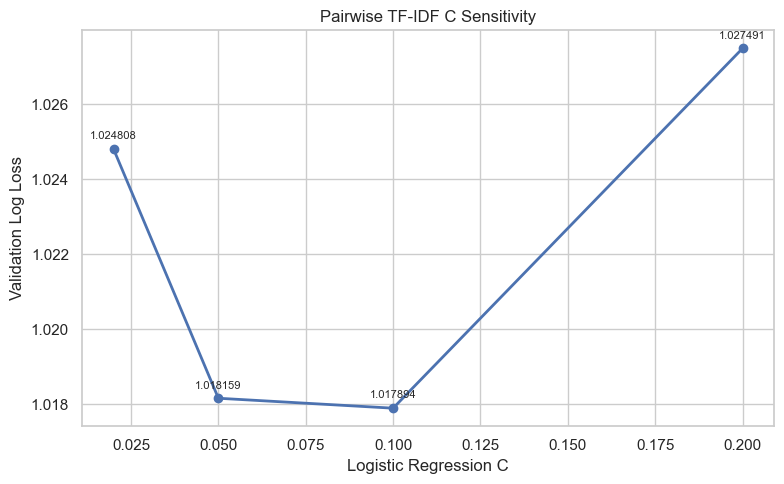

Saved: D:\LLM_Classification_finetuning\outputs\figures\pairwise_tfidf_c_log_loss.png


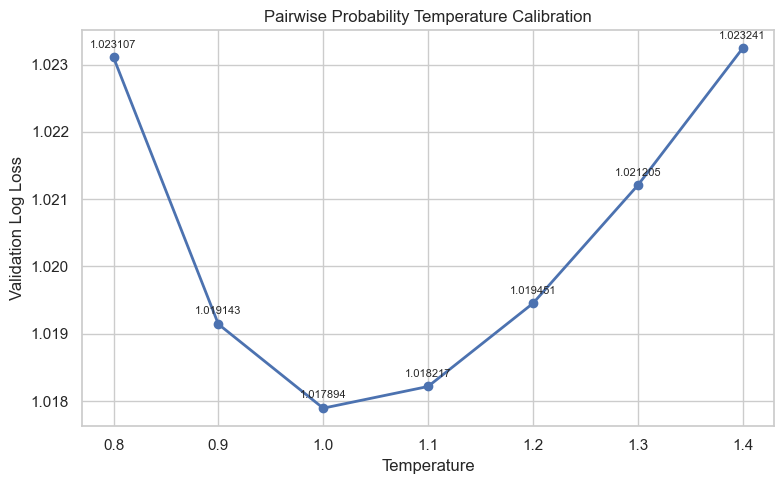

Saved: D:\LLM_Classification_finetuning\outputs\figures\pairwise_temperature_log_loss.png


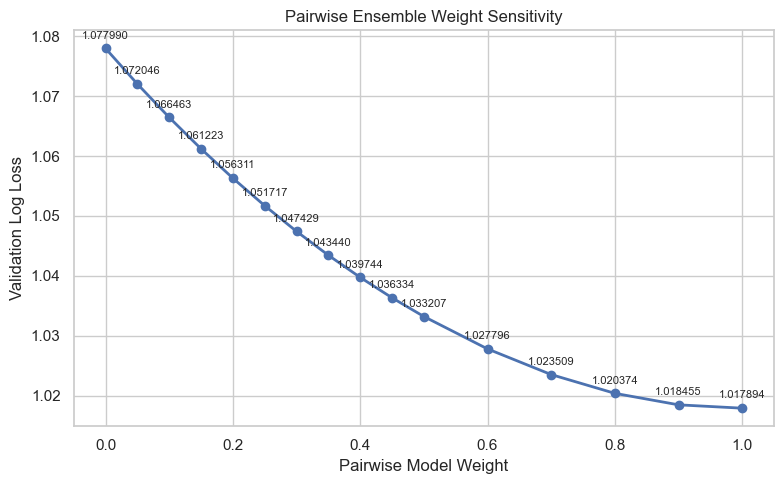

Saved: D:\LLM_Classification_finetuning\outputs\figures\pairwise_ensemble_weight_log_loss.png


In [13]:
def save_metric_plot(data, x, y, title, xlabel, path, marker='o'):
    plot_data = data.sort_values(x)
    plt.figure(figsize=(8, 5))
    plt.plot(plot_data[x], plot_data[y], marker=marker, linewidth=2)
    for x_value, y_value in zip(plot_data[x], plot_data[y]):
        plt.annotate(
            f'{y_value:.6f}', (x_value, y_value),
            xytext=(0, 7), textcoords='offset points', ha='center', fontsize=8,
        )
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Validation Log Loss')
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved:', path)

save_metric_plot(
    tuning_results, 'C', 'valid_log_loss',
    'Pairwise TF-IDF C Sensitivity', 'Logistic Regression C',
    FIGURE_DIR / 'pairwise_tfidf_c_log_loss.png',
)
save_metric_plot(
    temperature_results, 'temperature', 'valid_log_loss',
    'Pairwise Probability Temperature Calibration', 'Temperature',
    FIGURE_DIR / 'pairwise_temperature_log_loss.png',
)
save_metric_plot(
    ensemble_results, 'pairwise_weight', 'valid_log_loss',
    'Pairwise Ensemble Weight Sensitivity', 'Pairwise Model Weight',
    FIGURE_DIR / 'pairwise_ensemble_weight_log_loss.png',
)

## 14. Save Validation-stage Model Artifacts

Save the best validation model and fitted preprocessors. If the ensemble improves and full-data refitting runs below, these files are replaced with the full-data versions.

In [14]:
prompt_vectorizer_path = MODEL_DIR / 'pairwise_prompt_vectorizer.joblib'
response_vectorizer_path = MODEL_DIR / 'pairwise_response_vectorizer.joblib'
numeric_scaler_path = MODEL_DIR / 'pairwise_numeric_scaler.joblib'
pairwise_model_path = MODEL_DIR / 'pairwise_logistic_regression.joblib'

joblib.dump(prompt_vectorizer, prompt_vectorizer_path)
joblib.dump(response_vectorizer, response_vectorizer_path)
joblib.dump(numeric_scaler, numeric_scaler_path)
joblib.dump(best_pairwise_model, pairwise_model_path)
print('Saved validation-stage pairwise model artifacts.')

Saved validation-stage pairwise model artifacts.


## 15. Conditional Full-data Refit and Local Sample Submission

A local three-row sample submission is generated only when the best validation ensemble improves on 1.077990. Full-data vectorizers are fitted on original training text, while model fitting and numeric scaling use the full A/B-augmented training set.

In [15]:
submission_generated = False
submission_output_path = SUBMISSION_DIR / 'pairwise_final_ensemble_submission.csv'

if best_ensemble_valid_log_loss < expected_current_log_loss:
    print('Validation improved. Refitting pairwise pipeline on all training data...')
    full_swapped_train = swap_ab_dataframe(train)
    full_train_aug = pd.concat([train, full_swapped_train], ignore_index=True)

    full_prompt_vectorizer = TfidfVectorizer(
        analyzer='word', max_features=20000, ngram_range=(1, 2),
        min_df=2, max_df=0.95, sublinear_tf=True,
        strip_accents='unicode', dtype=np.float32,
    )
    full_response_vectorizer = TfidfVectorizer(
        analyzer='word', max_features=60000, ngram_range=(1, 2),
        min_df=2, max_df=0.95, sublinear_tf=True,
        strip_accents='unicode', dtype=np.float32,
    )
    full_prompt_vectorizer.fit(train['prompt_clean'])
    full_response_fit_text = pd.concat(
        [train['response_a_clean'], train['response_b_clean']], ignore_index=True
    )
    full_response_vectorizer.fit(full_response_fit_text)
    del full_response_fit_text
    gc.collect()

    full_train_text = build_pairwise_text_features(
        full_train_aug, full_prompt_vectorizer, full_response_vectorizer,
        dataset_name='full_train_aug',
    )
    test_text = build_pairwise_text_features(
        test, full_prompt_vectorizer, full_response_vectorizer, dataset_name='test'
    )
    full_numeric_raw = build_numeric_features(full_train_aug)
    test_numeric_raw = build_numeric_features(test)
    full_numeric_scaler = StandardScaler()
    full_numeric_scaled = full_numeric_scaler.fit_transform(full_numeric_raw).astype(np.float32)
    test_numeric_scaled = full_numeric_scaler.transform(test_numeric_raw).astype(np.float32)
    full_train_final = hstack(
        [full_train_text, csr_matrix(full_numeric_scaled)],
        format='csr', dtype=np.float32,
    )
    test_final = hstack(
        [test_text, csr_matrix(test_numeric_scaled)],
        format='csr', dtype=np.float32,
    )
    full_pairwise_model = LogisticRegression(
        C=best_pairwise_C, solver='saga', max_iter=800, tol=1e-3,
        n_jobs=-1, random_state=42,
    )
    full_pairwise_model.fit(full_train_final, full_train_aug['label'].to_numpy(dtype=np.int64))
    pairwise_test_probs_raw = full_pairwise_model.predict_proba(test_final)
    pairwise_test_probs = softmax(
        np.log(np.clip(pairwise_test_probs_raw, 1e-12, 1.0)) / best_temperature,
        axis=1,
    )

    ab_swap_submission_path = SUBMISSION_DIR / 'tfidf_lr_ab_swap_avg_submission.csv'
    word_char_submission_path = SUBMISSION_DIR / 'tfidf_word_char_ab_swap_tuned_submission.csv'
    for path in [ab_swap_submission_path, word_char_submission_path]:
        if not path.exists():
            raise FileNotFoundError(f'Required local submission not found: {path}')

    submission_probability_columns = ['winner_model_a', 'winner_model_b', 'winner_tie']
    ab_submission = pd.read_csv(ab_swap_submission_path, encoding='utf-8-sig')
    wc_submission = pd.read_csv(word_char_submission_path, encoding='utf-8-sig')
    if ab_submission['id'].duplicated().any() or wc_submission['id'].duplicated().any():
        raise ValueError('Duplicate ids found in existing local submissions.')
    current_submission = ab_submission[['id', *submission_probability_columns]].merge(
        wc_submission[['id', *submission_probability_columns]],
        on='id', how='inner', suffixes=('_ab', '_wc'), validate='one_to_one',
    )
    if set(current_submission['id']) != set(test['id']):
        raise ValueError('Existing submission ids do not match test_eda.csv ids.')
    current_submission = test[['id']].merge(
        current_submission, on='id', how='left', validate='one_to_one'
    )
    current_test_probs = (
        0.7 * current_submission[[f'{c}_ab' for c in submission_probability_columns]].to_numpy(dtype=np.float64)
        + 0.3 * current_submission[[f'{c}_wc' for c in submission_probability_columns]].to_numpy(dtype=np.float64)
    )
    final_test_probs = (
        best_pairwise_weight * pairwise_test_probs
        + best_current_final_weight * current_test_probs
    )
    submission = pd.DataFrame({
        'id': test['id'].to_numpy(),
        'winner_model_a': final_test_probs[:, 0],
        'winner_model_b': final_test_probs[:, 1],
        'winner_tie': final_test_probs[:, 2],
    })

    expected_columns = ['id', 'winner_model_a', 'winner_model_b', 'winner_tie']
    if submission.columns.tolist() != expected_columns:
        raise ValueError(f'Invalid submission columns: {submission.columns.tolist()}')
    if submission.shape != (len(test), 4):
        raise ValueError(f'Invalid submission shape: {submission.shape}')
    if submission[submission_probability_columns].isna().any().any():
        raise ValueError('Submission contains NaN probabilities.')
    if (submission[submission_probability_columns] < 0).any().any():
        raise ValueError('Submission contains negative probabilities.')
    if not np.allclose(submission[submission_probability_columns].sum(axis=1), 1.0, atol=1e-6):
        raise ValueError('Submission probability rows do not sum to 1.')

    submission.to_csv(submission_output_path, index=False, encoding='utf-8-sig')
    submission_generated = True
    print('submission shape:', submission.shape)
    print('submission columns:', submission.columns.tolist())
    print('submission contains NaN:', submission[submission_probability_columns].isna().any().any())
    print('submission contains negative probabilities:', (submission[submission_probability_columns] < 0).any().any())
    print('probability sums close to 1:', np.allclose(submission[submission_probability_columns].sum(axis=1), 1.0, atol=1e-6))
    display(submission.head())
    print('Saved:', submission_output_path)

    joblib.dump(full_prompt_vectorizer, prompt_vectorizer_path)
    joblib.dump(full_response_vectorizer, response_vectorizer_path)
    joblib.dump(full_numeric_scaler, numeric_scaler_path)
    joblib.dump(full_pairwise_model, pairwise_model_path)
    print('Replaced saved artifacts with full-data fitted versions.')

    del full_swapped_train, full_train_aug, full_train_text, test_text
    del full_numeric_raw, test_numeric_raw, full_numeric_scaled, test_numeric_scaled
    del full_train_final, test_final, pairwise_test_probs_raw, pairwise_test_probs
    gc.collect()
else:
    print('Validation did not improve on 1.077990. Local sample submission was not generated.')

Validation improved. Refitting pairwise pipeline on all training data...
full_train_aug X_prompt shape: (114954, 20000); estimated memory: 37.65 MB
full_train_aug X_a shape: (114954, 60000); estimated memory: 145.52 MB
full_train_aug X_b shape: (114954, 60000); estimated memory: 145.52 MB
full_train_aug X_diff shape: (114954, 60000); estimated memory: 247.95 MB
full_train_aug X_abs_diff shape: (114954, 60000); estimated memory: 247.95 MB
full_train_aug X_sum shape: (114954, 60000); estimated memory: 247.99 MB
full_train_aug X_text shape: (114954, 200000); estimated memory: 780.23 MB
test X_prompt shape: (3, 20000); estimated memory: 0.00 MB
test X_a shape: (3, 60000); estimated memory: 0.00 MB
test X_b shape: (3, 60000); estimated memory: 0.00 MB
test X_diff shape: (3, 60000); estimated memory: 0.01 MB
test X_abs_diff shape: (3, 60000); estimated memory: 0.01 MB
test X_sum shape: (3, 60000); estimated memory: 0.01 MB
test X_text shape: (3, 200000); estimated memory: 0.02 MB
submission 

,id,winner_model_a,winner_model_b,winner_tie
0,136060,0.204407,0.393866,0.401726
1,211333,0.357186,0.280936,0.361879
2,1233961,0.320464,0.469573,0.209963


Saved: D:\LLM_Classification_finetuning\outputs\submissions\pairwise_final_ensemble_submission.csv
Replaced saved artifacts with full-data fitted versions.


## 16. Generate Experiment Report

Write a concise Markdown record of the design, selected parameters, calibration result, ensemble result, and an honest interpretation.

In [16]:
improved = best_ensemble_valid_log_loss < expected_current_log_loss
improvement = expected_current_log_loss - best_ensemble_valid_log_loss
if improved:
    result_statement = (
        f'The ensemble improved log loss by {improvement:.6f} relative to 1.077990. '
        'This suggests the pairwise representation adds a small amount of complementary information.'
    )
else:
    result_statement = (
        f'The ensemble did not improve on 1.077990; its best log loss was '
        f'{best_ensemble_valid_log_loss:.6f}. The pairwise model may overlap strongly with the existing '
        'TF-IDF models, or its explicit differences may discard useful response-specific context.'
    )

report_text = f"""# Pairwise TF-IDF Difference Experiment

## Motivation

The previous models concatenate Prompt, Response A, and Response B into one input. This experiment instead gives both responses a shared TF-IDF space and explicitly represents how they differ. The goal is to expose directional evidence for A versus B while preserving signals useful for tie prediction.

## Feature Design

- `X_diff = X_a - X_b` represents words and phrases that occur more strongly in one response than the other, including direction.
- `X_abs_diff = abs(X_a - X_b)` represents the magnitude of response differences without direction.
- `X_sum = 0.5 * (X_a + X_b)` represents shared overall response content and may help identify ties.
- Prompt TF-IDF and ten scaled numeric difference features provide task context and compact structural asymmetry signals.

## Pairwise Model Result

- Best Logistic Regression C: {best_pairwise_C}
- Validation log loss before calibration: {best_pairwise_valid_log_loss:.6f}
- Validation accuracy: {best_pairwise_valid_accuracy:.6f}
- Validation macro F1: {best_pairwise_valid_macro_f1:.6f}

## Temperature Calibration

- Best temperature: {best_temperature}
- Calibrated pairwise validation log loss: {best_temperature_log_loss:.6f}

## Ensemble with the Current Final Model

- Rebuilt current final model log loss: {current_final_log_loss:.6f}
- Best pairwise weight: {best_pairwise_weight:.2f}
- Best current-final weight: {best_current_final_weight:.2f}
- Best ensemble validation log loss: {best_ensemble_valid_log_loss:.6f}
- Best ensemble validation accuracy: {best_ensemble_valid_accuracy:.6f}
- Best ensemble validation macro F1: {best_ensemble_valid_macro_f1:.6f}
- Local sample submission generated: {submission_generated}

## Conclusion

{result_statement}

Because all components are linear TF-IDF models, their errors can remain highly correlated. Pairwise subtraction improves structural comparison but still cannot directly judge factual correctness, deep reasoning, or nuanced human preference.
"""

report_path = REPORT_DIR / 'pairwise_tfidf_experiment.md'
report_path.write_text(report_text, encoding='utf-8')
print('Saved:', report_path)

Saved: D:\LLM_Classification_finetuning\report\pairwise_tfidf_experiment.md


## 17. Final Summary

Display the selected settings and release large validation matrices before finishing.

In [17]:
print('best_pairwise_C:', best_pairwise_C)
print('best_pairwise_valid_log_loss:', best_pairwise_valid_log_loss)
print('best_temperature:', best_temperature)
print('best_pairwise_weight:', best_pairwise_weight)
print('best_current_final_weight:', best_current_final_weight)
print('best_ensemble_valid_log_loss:', best_ensemble_valid_log_loss)
print('best_ensemble_valid_accuracy:', best_ensemble_valid_accuracy)
print('best_ensemble_valid_macro_f1:', best_ensemble_valid_macro_f1)
print('submission_generated:', submission_generated)

del x_train_final, x_valid_final
gc.collect()
print('Pairwise TF-IDF difference experiment finished successfully.')

best_pairwise_C: 0.1
best_pairwise_valid_log_loss: 1.0178942459548235
best_temperature: 1.0
best_pairwise_weight: 1.0
best_current_final_weight: 0.0
best_ensemble_valid_log_loss: 1.017894247085135
best_ensemble_valid_accuracy: 0.4880828114126653
best_ensemble_valid_macro_f1: 0.4828415438001457
submission_generated: True
Pairwise TF-IDF difference experiment finished successfully.
